# Ranking peptides for a fixed receptor — combinatorial peptide libraries

Which peptides does *this* receptor read? The other ranking task, and the one where nothing at all is
fitted: the read-out is `peptide_score`, the poly-alanine-referenced recognition energy summed over the
two peptide-bearing interfaces, sign-flipped so higher is better.

$$\texttt{peptide\_score} = -\bigl(\Delta\Phi_{\mathrm{TCR:pep}} + \Delta\Phi_{\mathrm{pep:MHC}}\bigr),
\qquad \Delta\Phi = \Phi(\text{sequence}) - \Phi(\text{poly-alanine})$$

$\Phi$ is the sum of a residue-pair statistical potential over the observed contacts of one interface
— TCRen on TCR:peptide, Miyazawa–Jernigan on peptide:MHC. The `d` in $\Delta\Phi$ is the **reference
difference**, never a derivative. Both interfaces enter because the assay reads T-cell activation,
which needs the peptide presented as well as the receptor engaged. The third interface, TCR:MHC, is
identically unchanged when only the peptide varies and cancels exactly.

The benchmark is the deposited combinatorial-peptide-library set: **7 T-cell clones, 2,103 TCRmodel2
peptide-swap models**, each clone's library split into the measured best and worst halves by a
positional-scanning activation assay.

**Needs**: the MHC allele reference (`tcren build-mhc-ref`, once). The featurisation asks for the
`energetics` family only, which is the cheap one.

In [1]:
# Environment. No score in this notebook samples; the only randomness is the plot's
# jitter, drawn from a seeded generator so the figure is reproducible.
import platform, sys

import numpy as np
import polars as pl
import scipy
import sklearn

import tcren

print(f"python     {platform.python_version()}")
print(f"tcren      {tcren.__version__}")
print(f"numpy      {np.__version__}")
print(f"polars     {pl.__version__}")
print(f"scipy      {scipy.__version__}")
print(f"scikit     {sklearn.__version__}")


python     3.12.13
tcren      3.0.0
numpy      2.5.1
polars     1.43.0
scipy      1.18.0
scikit     1.9.0


## 1 · Bootstrap the library

The set is `cpl/` on the Hugging Face dataset
[`isalgo/tcren_structures`](https://huggingface.co/datasets/isalgo/tcren_structures): one archive of
2,103 models laid out as `<clone>_{best,worst}/<peptide>.pdb`, plus the assay table
`CPL_stats/cpl_data_stats_new_struct.tsv` carrying the graded activation score `cpl_score` for 2,102
(clone, peptide) pairs.

The archive holds one structure the assay table does not: clone `sb27`'s own cognate 13-mer
`LPEPLPQGQLTAY`, modelled after the library deposit. It joins to nothing, and any count of structures
per clone has to say so.

**The best/worst label comes from the directory, not from the assay table's `cpl_status` column.** The
directories label all 2,103 models; `cpl_status` labels 1,654 and leaves 448 null.

In [2]:
# Fetch and unpack the library. Idempotent.
import os, tarfile, time
from pathlib import Path

from tcren.paper.bootstrap import fetch_hf_structures

DATA = Path(os.environ.get("TCREN_NB_DATA", "data"))
SET = DATA / "cpl"

if not (SET / "mel5_best").is_dir():
    fetch_hf_structures(DATA, folders=("cpl",))
    with tarfile.open(SET / "cpl_structures.tar.gz") as tar:
        tar.extractall(SET)

halves = sorted(p for p in SET.iterdir() if p.is_dir() and p.name.endswith(("_best", "_worst")))
clones = sorted({p.name.rsplit("_", 1)[0] for p in halves})
print(f"clones            {clones}")
print(f"clone x half dirs {len(halves)}")
print(f"structures        {sum(len(list(p.glob('*.pdb'))) for p in halves)}")

# The assay table ships under CPL_stats/ in the deposit; find it wherever the fetch put it.
stats = next(SET.rglob("cpl_data_stats_new_struct.tsv"))
assay = pl.read_csv(stats, separator="\t",
                    infer_schema_length=None).rename({"tcr": "clone", "peptide": "complex.id"})
print(f"assay rows        {assay.height}  (graded activation `cpl_score` per clone x peptide)")


clones            ['1e6', '4c6', '868', 'ila1', 'mel5', 'mel8', 'sb27']
clone x half dirs 14
structures        2103
assay rows        2102  (graded activation `cpl_score` per clone x peptide)


## 2 · Featurise, one clone-half at a time

`peptide_score` needs two descriptors, `dPhi_tcr_pep` and `dPhi_pep_mhc`, so only the `energetics`
family is asked for. The exact command per directory:

```bash
tcren features -s "data/cpl/mel5_best/*.pdb" -i energetics -t 0 -o data/cpl/mel5_best.tsv
```

One call per directory rather than one over the whole set, for a reason worth knowing: a structure's id
is its file stem, which here is the **peptide**, and the same peptide can occur in more than one
clone's library. A single pass would produce a table whose key is not unique. Featurising per directory
lets the clone and the half be recorded as columns.

Measured here: **2,103 structures in 279 s over 14 calls on 16 cores**. The cached table is used when
it is already on disk.

In [3]:
# Descriptors for every clone-half, tagged with the clone and the measured half.
import subprocess

FEATURES = SET / "features_energetics.tsv"

if not FEATURES.exists():
    t0, frames = time.time(), []
    for d in halves:
        clone, half = d.name.rsplit("_", 1)
        out = SET / f"{d.name}.tsv"
        subprocess.run([sys.executable, "-m", "tcren", "features", "-s", f"{d}/*.pdb",
                        "-i", "energetics", "-t", "0", "-o", str(out)],
                       check=True, capture_output=True, text=True)
        frames.append(pl.read_csv(out, separator="\t", infer_schema_length=None)
                        .with_columns(pl.lit(clone).alias("clone"), pl.lit(half).alias("half")))
    pl.concat(frames, how="vertical_relaxed").write_csv(FEATURES, separator="\t")
    print(f"featurised {sum(f.height for f in frames)} structures in {time.time() - t0:.0f} s")

feats = pl.read_csv(FEATURES, separator="\t", infer_schema_length=None)
print(f"{feats.height} rows x {len(feats.columns) - 3} descriptors")
print(feats.group_by("clone", "half").len().sort("clone", "half"))


featurised 2103 structures in 279 s
2103 rows x 15 descriptors
shape: (14, 3)
┌───────┬───────┬─────┐
│ clone ┆ half  ┆ len │
│ ---   ┆ ---   ┆ --- │
│ str   ┆ str   ┆ u32 │
╞═══════╪═══════╪═════╡
│ 1e6   ┆ best  ┆ 161 │
│ 1e6   ┆ worst ┆ 164 │
│ 4c6   ┆ best  ┆ 161 │
│ 4c6   ┆ worst ┆ 160 │
│ 868   ┆ best  ┆ 161 │
│ …     ┆ …     ┆ …   │
│ mel5  ┆ worst ┆ 164 │
│ mel8  ┆ best  ┆ 164 │
│ mel8  ┆ worst ┆ 96  │
│ sb27  ┆ best  ┆ 162 │
│ sb27  ┆ worst ┆ 64  │
└───────┴───────┴─────┘


## 3 · The score, and nothing is fitted in it

`tcren.score.peptide_score` is tier 0: no transform, no covariance, no hold-out, no coefficient. The
direction is fixed by the potential, and the potential is Boltzmann-inverted from crystal contact
statistics.

This is the instrument for peptide ranking against a fixed receptor, and it is **not** the instrument
for receptor ranking: on a receptor benchmark it reads below chance, which is a property of the
reference frame rather than a defect. `score_vdjdb_panel.ipynb` is the receptor task.

In [4]:
# Tier 0: the poly-alanine-referenced recognition energy over both peptide-bearing interfaces.
from tcren.score import peptide_score

lib = feats.with_columns(pl.Series("peptide_score", peptide_score(feats)))
lib = lib.with_columns((pl.col("half") == "best").cast(pl.Int8).alias("y"))
lib.select("complex.id", "clone", "half", "dPhi_tcr_pep", "dPhi_pep_mhc", "peptide_score").head(5)


complex.id,clone,half,dPhi_tcr_pep,dPhi_pep_mhc,peptide_score
str,str,str,f64,f64,f64
"""ALWGPDPAAA""","""1e6""","""best""",-0.450486,-4.98,5.430486
"""CIFGPDFKVV""","""1e6""","""best""",1.007804,-7.93,6.922196
"""CIFGPDFPVI""","""1e6""","""best""",2.865593,-10.41,7.544407
"""CIFGPDWKVI""","""1e6""","""best""",1.389202,-8.23,6.840798
"""CIFGPDWKVV""","""1e6""","""best""",1.389202,-7.67,6.280798


### Why the reference, and why two interfaces

Each of these 2,103 models carries its **own** generated pose: the peptide was swapped and the complex
re-folded, so neither the receptor nor the groove is held fixed across a clone's library. Measured
below, the TCR:MHC energy $\Phi_{\mathrm{TCR:MHC}}$ spans several statistical-potential units *within*
a single clone even though no clone changes its receptor or its allele.

That spread is the reason the score is built on $\Delta\Phi$ and not on $\Phi$. A raw interface energy
read off an independently generated complex partly reports the pose the generator chose rather than the
peptide it was asked about; the poly-alanine reference subtracts what the placement contributes and
leaves the sequence's. The two peptide-bearing interfaces are the two that the reference difference is
non-zero on — the third cancels identically when the peptide is threaded on a **fixed** contact map,
which is what section 7 does.


In [5]:
# Each model carries its own generated pose, so even the receptor-side energy moves within a clone.
# This is what the poly-alanine reference in peptide_score is there to remove.
for (clone,), g in sorted(lib.group_by("clone"), key=lambda kv: kv[0][0]):
    v = g["Phi_tcr_mhc"].to_numpy()
    print(f"{clone:5s}  n = {len(v):4d}   Phi_tcr_mhc  min {v.min():+7.3f}  max {v.max():+7.3f}  "
          f"spread {v.max() - v.min():.2f}")


1e6    n =  325   Phi_tcr_mhc  min  -3.650  max  +3.030  spread 6.68
4c6    n =  321   Phi_tcr_mhc  min  -2.410  max  +5.130  spread 7.54
868    n =  321   Phi_tcr_mhc  min  -1.810  max  +2.050  spread 3.86
ila1   n =  325   Phi_tcr_mhc  min  -4.030  max  +4.300  spread 8.33
mel5   n =  325   Phi_tcr_mhc  min  -0.000  max  +5.410  spread 5.41
mel8   n =  260   Phi_tcr_mhc  min  -2.630  max  +4.800  spread 7.43
sb27   n =  226   Phi_tcr_mhc  min  -5.150  max  +1.200  spread 6.35


## 4 · Per-clone ranking

Each clone is its own ranking problem: its library's best half against its own worst half, ranked by
`peptide_score`. Nothing is standardised across clones and nothing is pooled — the receptor differs, so
the absolute energies are not comparable between rows of the table below.

In [6]:
# ROC-AUC of peptide_score, best half against worst half, one row per clone.
from sklearn.metrics import average_precision_score, roc_auc_score

rows = []
for (clone,), g in sorted(lib.group_by("clone"), key=lambda kv: kv[0][0]):
    y, v = g["y"].to_numpy(), g["peptide_score"].to_numpy()
    ok = np.isfinite(v)
    rows.append({"clone": clone, "n": len(y), "n_best": int(y.sum()),
                 "roc_auc": roc_auc_score(y[ok], v[ok]),
                 "pr_auc": average_precision_score(y[ok], v[ok])})
per_clone = pl.DataFrame(rows)

roc = per_clone["roc_auc"].to_numpy()
print(f"median per-clone ROC-AUC  {np.median(roc):.3f}")
print(f"clones above chance       {int((roc > 0.5).sum())} of {len(roc)}")
print(f"clones above 0.90         {int((roc > 0.9).sum())} of {len(roc)}")
per_clone


median per-clone ROC-AUC  0.999
clones above chance       7 of 7
clones above 0.90         6 of 7


clone,n,n_best,roc_auc,pr_auc
str,i64,i64,f64,f64
"""1e6""",325,161,0.999508,0.99951
"""4c6""",321,161,0.987733,0.987205
"""868""",321,161,0.704503,0.592189
"""ila1""",325,161,1.0,1.0
"""mel5""",325,161,1.0,1.0
"""mel8""",260,164,0.952807,0.973744
"""sb27""",226,162,0.998843,0.999552


Six of the seven clones separate their own library halves almost perfectly. The seventh, `868`, does
not, and its cognate epitope is the HIV-1 Gag p17 nonamer `SLYNTVATL`. It is reported here rather than
dropped: a per-clone table shows which receptor the instrument works on, which a pooled AUC over 2,103
models cannot.

## 5 · The graded read-out

Best-against-worst is a binarisation of a continuous measurement: `cpl_score` is the assayed activation
itself, and the deposited halves are the top and the bottom of that same quantity. Reporting the rank
correlation against it puts the ranking on the assay's own scale rather than on a threshold applied
to it.

Spearman, because neither the assay's units nor the potential's are on a common interval scale. Within
clone, because pooling across receptors would read a between-receptor offset rather than a within-library
ordering — the absolute energies in the table above are not comparable between clones.

In [7]:
# Spearman rho of peptide_score against the graded activation score, within clone.
from scipy.stats import spearmanr

graded = lib.join(assay.select("complex.id", "clone", "cpl_score"),
                  on=["complex.id", "clone"], how="inner")
print(f"joined {graded.height} of {lib.height} structures "
      f"({lib.height - graded.height} not in the assay table)")

rows = []
for (clone,), g in sorted(graded.group_by("clone"), key=lambda kv: kv[0][0]):
    v, a = g["peptide_score"].to_numpy(), g["cpl_score"].to_numpy()
    ok = np.isfinite(v) & np.isfinite(a)
    rho, p = spearmanr(v[ok], a[ok])
    rows.append({"clone": clone, "n": int(ok.sum()), "spearman_rho": rho, "p_value": p})
per_clone_rho = pl.DataFrame(rows)
print(f"\nmedian within-clone Spearman rho  "
      f"{np.median(per_clone_rho['spearman_rho'].to_numpy()):.3f}")
per_clone_rho


joined 2102 of 2103 structures (1 not in the assay table)

median within-clone Spearman rho  0.708


clone,n,spearman_rho,p_value
str,i64,f64,f64
"""1e6""",325,0.76232,5.3644e-63
"""4c6""",321,0.708071,3.9326e-50
"""868""",321,0.189854,0.000628
"""ila1""",325,0.765402,8.6068e-64
"""mel5""",325,0.790535,9.2162e-71
"""mel8""",260,0.464795,2.4371e-15
"""sb27""",225,0.582682,7.4592e-22


## 6 · Drawn

Left: the score distribution per clone, measured best half against measured worst half. Right: the
graded read-out for one clone, `peptide_score` against the assay's activation score.

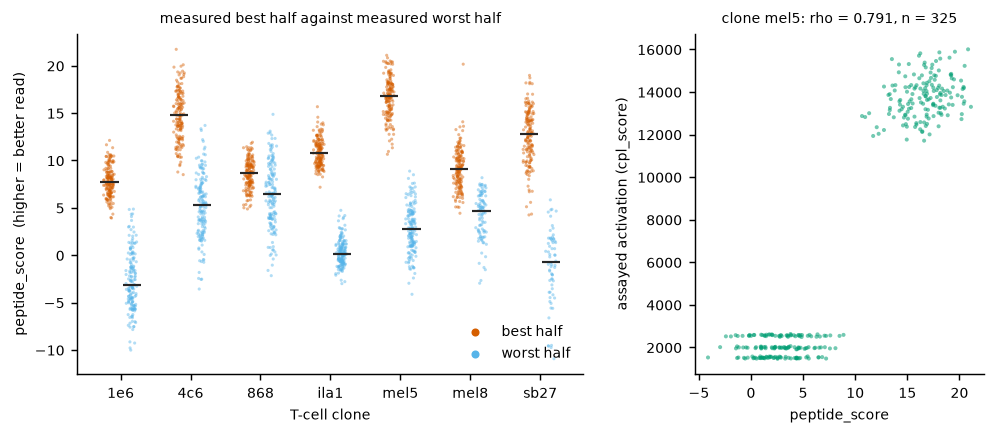

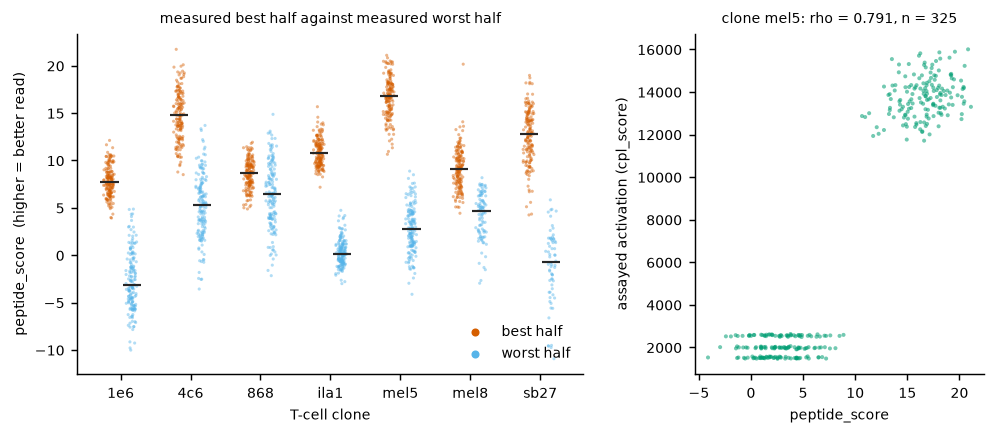

In [8]:
%matplotlib inline
# Per-clone separation and the graded relation for one clone. Okabe-Ito palette.
import matplotlib.pyplot as plt

BEST, WORST = "#D55E00", "#56B4E9"
SHOW = "mel5"

plt.rcParams.update({"font.size": 8, "axes.spines.top": False, "axes.spines.right": False,
                     "figure.dpi": 130})
fig, (ax0, ax1) = plt.subplots(1, 2, figsize=(9.0, 3.4),
                               gridspec_kw={"width_ratios": [7, 4], "wspace": 0.28})

order = sorted(set(lib["clone"]))
for i, clone in enumerate(order):
    for half, colour, dx in (("best", BEST, -0.16), ("worst", WORST, 0.16)):
        v = lib.filter((pl.col("clone") == clone) & (pl.col("half") == half))["peptide_score"]
        v = v.to_numpy()
        ax0.scatter(np.full(len(v), i + dx) + np.random.default_rng(0).normal(0, 0.035, len(v)),
                    v, s=3, color=colour, alpha=0.45, edgecolor="none", zorder=2)
        ax0.hlines(np.median(v), i + dx - 0.13, i + dx + 0.13, color="0.15", lw=1.2, zorder=3)
ax0.set_xticks(range(len(order)))
ax0.set_xticklabels(order)
ax0.set_xlabel("T-cell clone")
ax0.set_ylabel("peptide_score  (higher = better read)")
ax0.set_title("measured best half against measured worst half", fontsize=8)
ax0.scatter([], [], s=12, color=BEST, label="best half")
ax0.scatter([], [], s=12, color=WORST, label="worst half")
ax0.legend(frameon=False, loc="lower right")

g = graded.filter(pl.col("clone") == SHOW)
rho = float(per_clone_rho.filter(pl.col("clone") == SHOW)["spearman_rho"][0])
ax1.scatter(g["peptide_score"].to_numpy(), g["cpl_score"].to_numpy(), s=5,
            color="#009E73", alpha=0.55, edgecolor="none")
ax1.set_xlabel("peptide_score")
ax1.set_ylabel("assayed activation (cpl_score)")
ax1.set_title(f"clone {SHOW}: rho = {rho:.3f}, n = {g.height}", fontsize=8)
fig


## 7 · The other direction — a response matrix from one template

The library above scores 2,103 models, one per peptide. The same question can be asked of a **single**
structure: thread all twenty residues through each contacting peptide position on the template's own
contact map and re-read the potential. That is `tcren cpl`, and it costs one batched call per interface
rather than one model per peptide.

Two reference states come out, and a cell means nothing except against one of them. `effect_equimolar`
scores a residue against the 1/20 mixture, which is what a positional-scanning library actually
realises and the right axis against a measured matrix. `effect_wild_type` scores it against the residue
the template carries, which is the mutation-scan and neoantigen question. Positive is favourable on
both.

In [9]:
# The predicted response matrix of one template: clone mel5 on its cognate ELAGIGILTV.
TEMPLATE = SET / "mel5_best" / "ELAGIGILTV.pdb"
MATRIX = SET / "mel5_response_matrix.csv"

if not MATRIX.exists():
    subprocess.run([sys.executable, "-m", "tcren", "cpl", "-s", str(TEMPLATE), "-o", str(MATRIX)],
                   check=True, capture_output=True, text=True)

rm = pl.read_csv(MATRIX)
print(f"{rm.height} cells = {rm['pos'].n_unique()} contacting positions x {rm['aa'].n_unique()} residues")
print(rm.group_by("interface_class").len().sort("interface_class"))
rm.sort("effect_equimolar", descending=True).select(
    "pos", "wt_aa", "aa", "interface_class", "effect_equimolar", "effect_wild_type").head(8)


200 cells = 10 contacting positions x 20 residues
shape: (2, 2)
┌─────────────────┬─────┐
│ interface_class ┆ len │
│ ---             ┆ --- │
│ str             ┆ u32 │
╞═════════════════╪═════╡
│ anchor          ┆ 20  │
│ receptor        ┆ 180 │
└─────────────────┴─────┘


pos,wt_aa,aa,interface_class,effect_equimolar,effect_wild_type
i64,str,str,str,f64,f64
8,"""L""","""I""","""receptor""",3.242278,1.159913
2,"""L""","""F""","""receptor""",2.961986,0.30304
2,"""L""","""L""","""receptor""",2.658945,0.0
5,"""I""","""I""","""receptor""",2.569968,0.0
1,"""E""","""F""","""receptor""",2.525986,3.915961
7,"""I""","""I""","""receptor""",2.502446,0.0
1,"""E""","""L""","""receptor""",2.302945,3.69292
6,"""G""","""I""","""receptor""",2.236826,2.295054


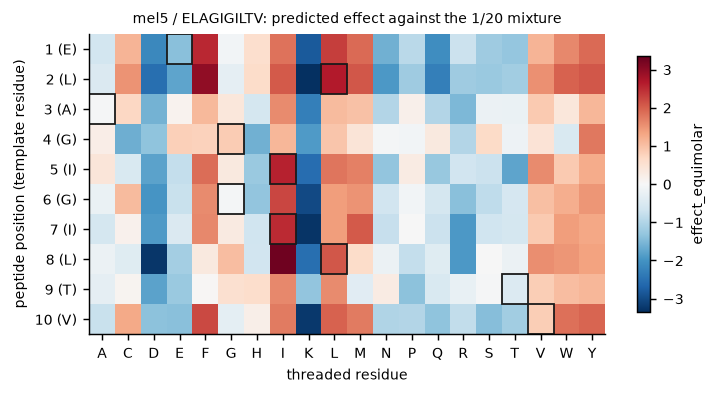

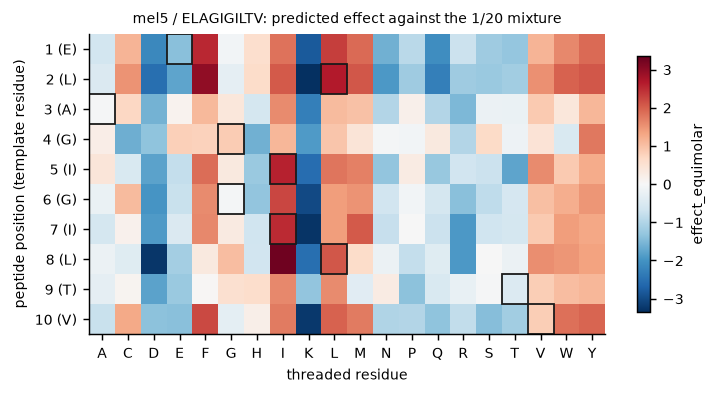

In [10]:
# The matrix as a heat map: positions down, residues across, scored against the 1/20 mixture.
AA = list("ACDEFGHIKLMNPQRSTVWY")
positions = sorted(rm["pos"].unique().to_list())
grid = np.full((len(positions), len(AA)), np.nan)
lookup = {(r["pos"], r["aa"]): r["effect_equimolar"] for r in rm.iter_rows(named=True)}
for i, p in enumerate(positions):
    for j, a in enumerate(AA):
        grid[i, j] = lookup.get((p, a), np.nan)

wt = {r["pos"]: r["wt_aa"] for r in rm.iter_rows(named=True)}
lim = np.nanmax(np.abs(grid))

fig, ax = plt.subplots(figsize=(6.4, 3.0))
im = ax.imshow(grid, cmap="RdBu_r", vmin=-lim, vmax=lim, aspect="auto")
ax.set_xticks(range(len(AA)))
ax.set_xticklabels(AA)
ax.set_yticks(range(len(positions)))
ax.set_yticklabels([f"{p} ({wt[p]})" for p in positions])
ax.set_xlabel("threaded residue")
ax.set_ylabel("peptide position (template residue)")
ax.set_title("mel5 / ELAGIGILTV: predicted effect against the 1/20 mixture", fontsize=8)
for i, p in enumerate(positions):
    ax.add_patch(plt.Rectangle((AA.index(wt[p]) - 0.5, i - 0.5), 1, 1,
                               fill=False, edgecolor="0.1", lw=1.0))
fig.colorbar(im, ax=ax, shrink=0.85, label="effect_equimolar")
fig


## What this notebook establishes

- Peptide ranking for a fixed receptor runs end to end from deposited coordinates with **nothing
  fitted anywhere**: the direction is the potential's, and no binding label, no hold-out and no
  coefficient enters `peptide_score`.
- Reported **per clone**, because that is what says which receptor the instrument works on. Six of the
  seven clones separate their own library halves above 0.90 ROC-AUC; the seventh is reported at its
  measured value rather than dropped.
- On the assay's own continuous scale the within-clone rank correlation is positive in all seven
  clones, with a median Spearman rho of 0.71 over 2,102 assayed models.
- The same question asked of **one** structure is `tcren cpl`, which returns the whole
  position x residue matrix against two named reference states.

**What it does not claim.** Not affinity, and not a rank that transfers between receptors: an absolute
`peptide_score` from one clone's template cannot be compared with another clone's. And this is the
peptide task only -- on a receptor benchmark the same score reads below chance, which is the reference
frame speaking, not a defect.
